# NB00: configuration

- **Purpose:** define the study population, outcomes, source controls, inference settings, and simulation settings.
- **Pipeline:** configuration -> preparation -> EDA -> descriptive inference -> model-based simulation.
- **Inputs:** none.
- **Outputs:** the locked in-notebook configuration object and `artifacts/configuration_pipeline.svg`.
- **Run:** execute before NB01.
- **Locked definitions:** completed 12-team season-long snake drafts on Sleeper; best ball excluded; scoring and roster format may vary. Outcomes use regular-season points only. Top-six and top-scorer ties receive fractional credit.

| Gate | What it checks | Pass condition |
| ---: | --- | --- |
| 1 | League structure | Every retained league-season has 12 roster rows and slots 1 through 12 |
| 2 | Outcome accounting | Top-six and top-scorer credits sum to six and one per league-season |
| 3 | Simulation scope | 17 regular-season weeks, 12 teams, no playoff outcomes |


### What this cell does

- Records the shared study definitions and the fixed settings used by inference and simulation.
- Separates the bootstrap and Monte Carlo seeds so both workflows remain reproducible.


In [3]:
# CELL [1 study-configuration]
STUDY = {
    'candidate_seasons': list(range(2017, 2026)),
    'retained_seasons': list(range(2018, 2026)),
    'league_size': 12,
    'draft_type': 'snake',
    'exclude_best_ball': True,
    'source': 'Sleeper public API convenience-network sample',
    'outcomes': ['regular_season_points', 'top_6_points', 'top_regular_season_scorer'],
    'bootstrap_replicates': 2000,
    'bootstrap_random_seed': 20260811,
    'simulation_weeks': 17,
    'simulation_league_seasons_per_scenario': 100000,
    'simulation_random_seed': 20260812,
    'simulation_weekly_icc_scenarios': [0.05, 0.15, 0.30],
}
STUDY


{'candidate_seasons': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
 'retained_seasons': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
 'league_size': 12,
 'draft_type': 'snake',
 'exclude_best_ball': True,
 'source': 'Sleeper public API convenience-network sample',
 'outcomes': ['regular_season_points',
  'top_6_points',
  'top_regular_season_scorer'],
 'bootstrap_replicates': 2000,
 'bootstrap_random_seed': 20260811,
 'simulation_weeks': 17,
 'simulation_league_seasons_per_scenario': 100000,
 'simulation_random_seed': 20260812,
 'simulation_weekly_icc_scenarios': [0.05, 0.15, 0.3]}

### Interpreting the output

- The configuration covers retained seasons 2018 through 2025, 12 draft slots, three regular-season outcomes, 2,000 bootstrap draws, and 100,000 simulations per scenario.
- Separate fixed seeds make inference and simulation exactly reproducible.
- The 17-week simulation varies assumed weekly score persistence across 0.05, 0.15, and 0.30 correlations.
- These settings define descriptive and model-based analyses. They do not establish a causal draft-slot effect.


### What this cell does

- Writes a visual map of the five-notebook workflow.
- Separates observed descriptive inference in NB03 from model-based simulation in NB04.


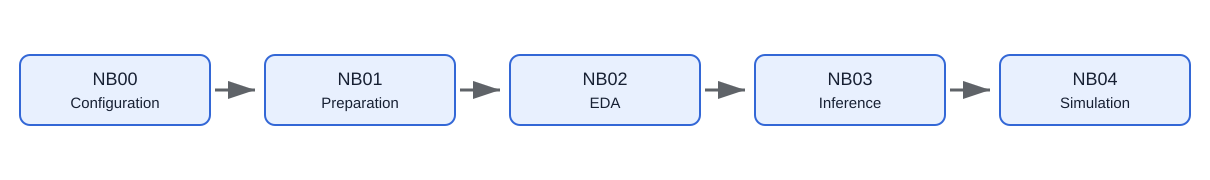

In [4]:
# CELL [2 pipeline-map-chart]
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
chart_path = ROOT / 'artifacts/configuration_pipeline.svg'
stages = [('NB00', 'Configuration'), ('NB01', 'Preparation'), ('NB02', 'EDA'), ('NB03', 'Inference'), ('NB04', 'Simulation')]
box_width, gap, left, y = 190, 55, 20, 55
width = left * 2 + len(stages) * box_width + (len(stages) - 1) * gap
boxes, arrows = [], []
for index, (number, label) in enumerate(stages):
    x = left + index * (box_width + gap)
    boxes.append(f'<rect class="box" x="{x}" y="{y}" width="{box_width}" height="70" rx="10"/><text x="{x + box_width / 2}" y="85" text-anchor="middle" font-size="18">{number}</text><text x="{x + box_width / 2}" y="108" text-anchor="middle" font-size="15">{label}</text>')
    if index < len(stages) - 1:
        arrows.append(f'<line class="arrow" x1="{x + box_width + 5}" y1="90" x2="{x + box_width + gap - 10}" y2="90"/>')
svg = f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="180" viewBox="0 0 {width} 180"><style>text{{font-family:Arial,sans-serif;fill:#172033}}.box{{fill:#e8f0fe;stroke:#3367d6;stroke-width:2}}.arrow{{stroke:#5f6368;stroke-width:3;marker-end:url(#a)}}</style><defs><marker id="a" markerWidth="10" markerHeight="10" refX="9" refY="3" orient="auto"><path d="M0,0 L0,6 L9,3 z" fill="#5f6368"/></marker></defs>{"".join(boxes)}{"".join(arrows)}</svg>'
chart_path.write_text(svg, encoding='utf-8')
try:
    from IPython.display import SVG, display
    display(SVG(filename=str(chart_path)))
except ImportError:
    print(chart_path)


### Interpreting the output

- The chart confirms five ordered stages: configuration, preparation, EDA, descriptive inference, and model-based simulation.
- NB02 through NB04 all use the same prepared 3,641-league panel.
- Keeping simulation separate prevents modeled rank probabilities from being confused with observed rates.
- The workflow map does not prove any draft-slot association or validate the simulation assumptions.


## Conclusion

- The study definitions, inference settings, and simulation settings are fixed for this pipeline run.
- NB00 writes only the workflow chart; NB01 owns the analysis-panel files.
- NB01 may run next when the retained caches and processed team-season file are present.
- This notebook does not determine whether any draft slot performs better.
